# CS-378: Design and Analysis of Algorithms — Semester Project
## Notebook 1: Dataset Acquisition, Parsing, Validation & Exploratory Data Analysis

**Project:** Comparison of Apriori with ProbDF (Sadeequllah et al., 2024) for Frequent Itemset Mining  
**Group Members:** Bilal Ahmad Sheikh (2023162), Muhammad Muzzammil Idrees (2023481)  
**Institution:** Ghulam Ishaq Khan Institute of Engineering Sciences and Technology  
**Course:** CS-378 Design and Analysis of Algorithms

---

### Notebook Overview
This notebook covers:
1. Environment setup and library installation
2. Download of all three benchmark datasets from the FIMI repository
3. Dataset parsing and format validation
4. Comprehensive Exploratory Data Analysis (EDA)
5. Dataset statistics table (for the report)
6. Saving clean parsed datasets for use in subsequent notebooks

### Runtime Selection
> **Use CPU Runtime** (default). All three algorithms (Apriori, FP-Growth, ProbDF) are memory-bound and CPU-bound. GPU provides no speedup for set operations and TID-list intersections. In Colab: `Runtime → Change runtime type → CPU`.
>
> **RAM Recommendation:** In Google Colab Free, use `Runtime → Connect to a runtime` with High-RAM if available (for the Accident dataset at low min_sup thresholds). If memory errors occur on Accident, use min_sup ≥ 0.7.

---

### Research Papers Implemented in This Project

| # | Paper | Algorithm | Role |
|---|-------|-----------|------|
| 1 | Agrawal & Srikant (1994). *Fast Algorithms for Mining Association Rules*. VLDB. | **Apriori** | Baseline |
| 2 | Han, Pei & Yin (2000). *Mining Frequent Patterns without Candidate Generation*. SIGMOD. | **FP-Growth** (via mlxtend) | Classic SOTA reference |
| 3 | **Sadeequllah et al. (2024)**. *Quick mining in dense data: applying probabilistic support prediction in depth-first order*. PeerJ Computer Science. DOI: 10.7717/peerj-cs.2334 | **ProbDF** | **Primary SOTA (2024)** |
| 4 | Zaki et al. (1997). *New Algorithms for Fast Discovery of Association Rules*. KDD. | **ECLAT / Tidset Optimization** | Optimization 1 for Apriori |
| 5 | Park, Chen & Yu (1995). *An Effective Hash-Based Algorithm for Mining Association Rules*. SIGMOD. | **HashTree Pruning** | Optimization 2 for Apriori |

---
## Section 1: Environment Setup

In [1]:
# Install required libraries
# mlxtend: provides Apriori and FP-Growth (we use it for FP-Growth ONLY in Notebook 3)
# psutil: for accurate memory measurement
# tabulate: for clean table printing
!pip install mlxtend psutil tabulate --quiet

In [2]:
import os
import sys
import time
import pickle
import tracemalloc
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter, defaultdict
from tabulate import tabulate

# Reproducibility
np.random.seed(42)

# Plot styling
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'font.family': 'DejaVu Sans'
})
sns.set_theme(style='whitegrid')

print(f'Python version: {sys.version}')
print('All libraries imported successfully.')

Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
All libraries imported successfully.


---
## Section 2: Dataset Download from FIMI Repository

The three benchmark datasets used in this project are:
- **Chess**: Game state records. Dense dataset, small item vocabulary, very high frequency.
- **Connect**: Game state records. Dense, highly correlated, stress-tests candidate pruning.
- **Accidents**: Belgian traffic accident records. Large-scale real-world data, tests scalability.

Source: FIMI Repository — http://fimi.uantwerpen.be/data/

In [5]:
# ─── Dataset Download ────────────────────────────────────────────────────────

DATA_DIR = './data'
os.makedirs(DATA_DIR, exist_ok=True)

# Using Internet Archive links since the original FIMI links are returning 404
DATASETS = {
    'chess':     'https://web.archive.org/web/20220812034032if_/http://fimi.uantwerpen.be/data/chess.dat',
    'connect':   'https://web.archive.org/web/20220812034032if_/http://fimi.uantwerpen.be/data/connect.dat',
    'accidents': 'https://web.archive.org/web/20220812034032if_/http://fimi.uantwerpen.be/data/accidents.dat',
}

def download_dataset(name, url, data_dir):
    filepath = os.path.join(data_dir, f'{name}.dat')
    if os.path.exists(filepath):
        size_mb = os.path.getsize(filepath) / (1024 * 1024)
        print(f'  [{name}] Already exists ({size_mb:.2f} MB). Skipping download.')
        return filepath
    print(f'  [{name}] Downloading from archive.org mirror ...')
    try:
        # Setting a User-Agent to avoid 403 Forbidden from archive.org occasionally
        req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req) as response, open(filepath, 'wb') as out_file:
            out_file.write(response.read())
        size_mb = os.path.getsize(filepath) / (1024 * 1024)
        print(f'  [{name}] Downloaded successfully ({size_mb:.2f} MB).')
    except Exception as e:
        print(f'  [{name}] ERROR: {e}')
        print(f'  [{name}] Please download manually and place at {filepath}')
    return filepath

print('Downloading benchmark datasets from FIMI repository (via Internet Archive)...')
filepaths = {}
for name, url in DATASETS.items():
    filepaths[name] = download_dataset(name, url, DATA_DIR)

print('\nDownload complete.')

  [chess] Downloading from archive.org mirror ...
  [chess] Downloaded successfully (0.33 MB).
  [connect] Downloading from archive.org mirror ...
  [connect] Downloaded successfully (8.83 MB).
  [accidents] Downloading from archive.org mirror ...
  [accidents] Downloaded successfully (33.86 MB).

Download complete.


---
## Section 3: Dataset Parsing

The `.dat` format from FIMI is a plain text format where each line represents one transaction, and items are space-separated integers.

In [6]:
# ─── Parsing Functions ────────────────────────────────────────────────────────

def parse_dat_file(filepath):
    """
    Parse a FIMI .dat file into a list of transactions.
    Each transaction is a frozenset of integer item IDs.
    frozenset is used for O(1) membership testing and hashability.
    """
    transactions = []
    with open(filepath, 'r') as f:
        for line_num, line in enumerate(f, 1):
            line = line.strip()
            if not line:        # skip empty lines
                continue
            items = frozenset(int(x) for x in line.split())
            if len(items) == 0: # skip degenerate empty transactions
                continue
            transactions.append(items)
    return transactions


def validate_dataset(name, transactions):
    """
    Validate parsed transactions and report any anomalies.
    """
    print(f'  [{name}] Total transactions: {len(transactions)}')
    if len(transactions) == 0:
        print(f'  [{name}] WARNING: No transactions parsed!')
        return False
    lengths = [len(t) for t in transactions]
    items   = set()
    for t in transactions:
        items.update(t)
    print(f'  [{name}] Unique items:        {len(items)}')
    print(f'  [{name}] Min tx length:       {min(lengths)}')
    print(f'  [{name}] Max tx length:       {max(lengths)}')
    print(f'  [{name}] Avg tx length:       {np.mean(lengths):.2f}')
    print(f'  [{name}] Item ID range:       [{min(items)}, {max(items)}]')
    return True


# ─── Parse All Datasets ───────────────────────────────────────────────────────
print('Parsing datasets...\n')
datasets = {}
for name, path in filepaths.items():
    print(f'Parsing [{name}]...')
    txns = parse_dat_file(path)
    validate_dataset(name, txns)
    datasets[name] = txns
    print()

Parsing datasets...

Parsing [chess]...
  [chess] Total transactions: 3196
  [chess] Unique items:        75
  [chess] Min tx length:       37
  [chess] Max tx length:       37
  [chess] Avg tx length:       37.00
  [chess] Item ID range:       [1, 75]

Parsing [connect]...
  [connect] Total transactions: 67557
  [connect] Unique items:        129
  [connect] Min tx length:       43
  [connect] Max tx length:       43
  [connect] Avg tx length:       43.00
  [connect] Item ID range:       [1, 129]

Parsing [accidents]...
  [accidents] Total transactions: 340183
  [accidents] Unique items:        468
  [accidents] Min tx length:       18
  [accidents] Max tx length:       51
  [accidents] Avg tx length:       33.81
  [accidents] Item ID range:       [1, 468]



---
## Section 4: Exploratory Data Analysis (EDA)

We compute and visualize the key characteristics that determine algorithmic behavior on each dataset.

In [7]:
# ─── Core Statistics per Dataset ─────────────────────────────────────────────

def compute_dataset_stats(name, transactions):
    lengths = np.array([len(t) for t in transactions])
    all_items = [item for t in transactions for item in t]
    unique_items = set(all_items)
    item_counts = Counter(all_items)
    num_tx = len(transactions)
    num_items = len(unique_items)

    # Density = avg(|transaction| / |all items|)
    density = np.mean(lengths) / num_items

    # Average support of individual items (fraction of transactions)
    avg_item_support = np.mean([c / num_tx for c in item_counts.values()])

    stats = {
        'Dataset':              name.capitalize(),
        '# Transactions':       num_tx,
        '# Unique Items':       num_items,
        'Min Tx Length':        int(lengths.min()),
        'Max Tx Length':        int(lengths.max()),
        'Avg Tx Length':        round(float(lengths.mean()), 2),
        'Std Tx Length':        round(float(lengths.std()), 2),
        'Median Tx Length':     round(float(np.median(lengths)), 2),
        'Density (%)':          round(density * 100, 2),
        'Avg Item Support (%)': round(avg_item_support * 100, 4),
    }
    return stats, lengths, item_counts


all_stats = []
all_lengths = {}
all_item_counts = {}

for name, txns in datasets.items():
    stats, lengths, item_counts = compute_dataset_stats(name, txns)
    all_stats.append(stats)
    all_lengths[name]      = lengths
    all_item_counts[name]  = item_counts

# Print formatted statistics table
stats_df = pd.DataFrame(all_stats).set_index('Dataset')
print('=' * 70)
print('DATASET STATISTICS TABLE (for Report Table)')
print('=' * 70)
print(tabulate(stats_df, headers='keys', tablefmt='grid'))

DATASET STATISTICS TABLE (for Report Table)
+-----------+------------------+------------------+-----------------+-----------------+-----------------+-----------------+--------------------+---------------+------------------------+
| Dataset   |   # Transactions |   # Unique Items |   Min Tx Length |   Max Tx Length |   Avg Tx Length |   Std Tx Length |   Median Tx Length |   Density (%) |   Avg Item Support (%) |
+===========+==================+==================+=================+=================+=================+=================+====================+===============+========================+
| Chess     |             3196 |               75 |              37 |              37 |           37    |            0    |                 37 |         49.33 |                49.3333 |
+-----------+------------------+------------------+-----------------+-----------------+-----------------+-----------------+--------------------+---------------+------------------------+
| Connect   |            6

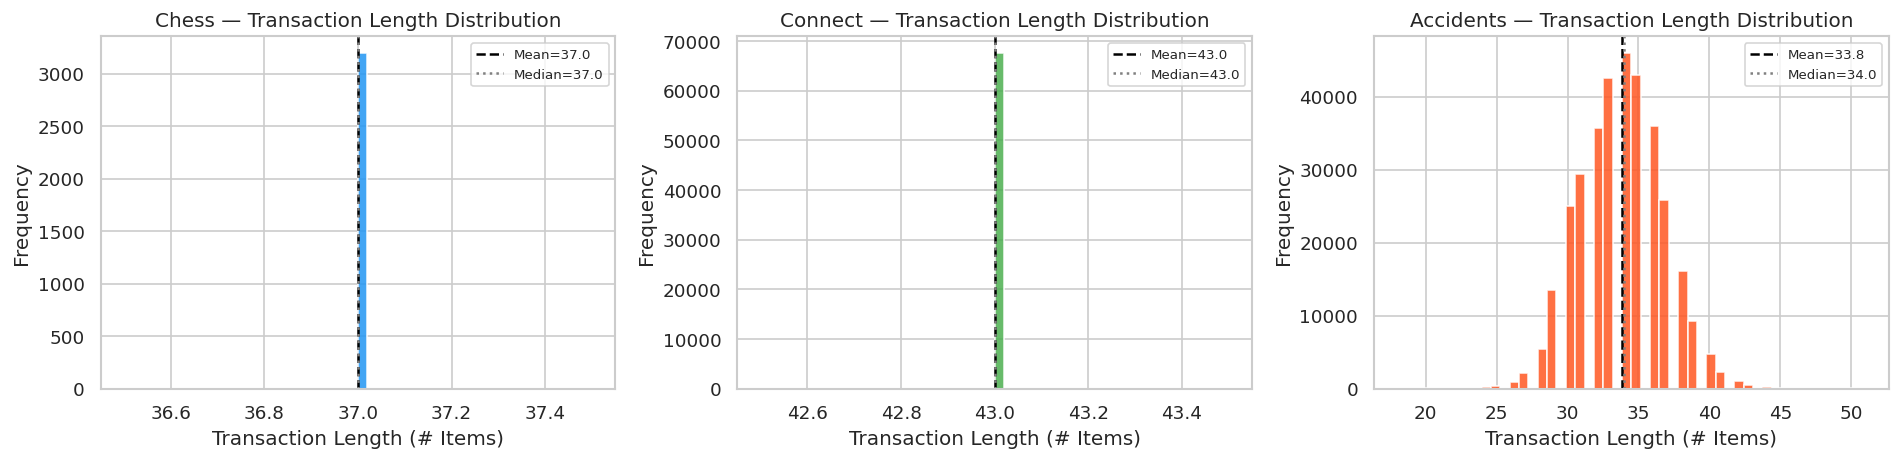

Figure saved: eda_transaction_length_dist.png


In [8]:
# ─── EDA Plot 1: Transaction Length Distributions ────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colors = ['#2196F3', '#4CAF50', '#FF5722']

for ax, (name, lengths), color in zip(axes, all_lengths.items(), colors):
    ax.hist(lengths, bins=50, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(lengths.mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'Mean={lengths.mean():.1f}')
    ax.axvline(np.median(lengths), color='gray', linestyle=':', linewidth=1.5,
               label=f'Median={np.median(lengths):.1f}')
    ax.set_title(f'{name.capitalize()} — Transaction Length Distribution')
    ax.set_xlabel('Transaction Length (# Items)')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('./data/eda_transaction_length_dist.png', bbox_inches='tight')
plt.show()
print('Figure saved: eda_transaction_length_dist.png')

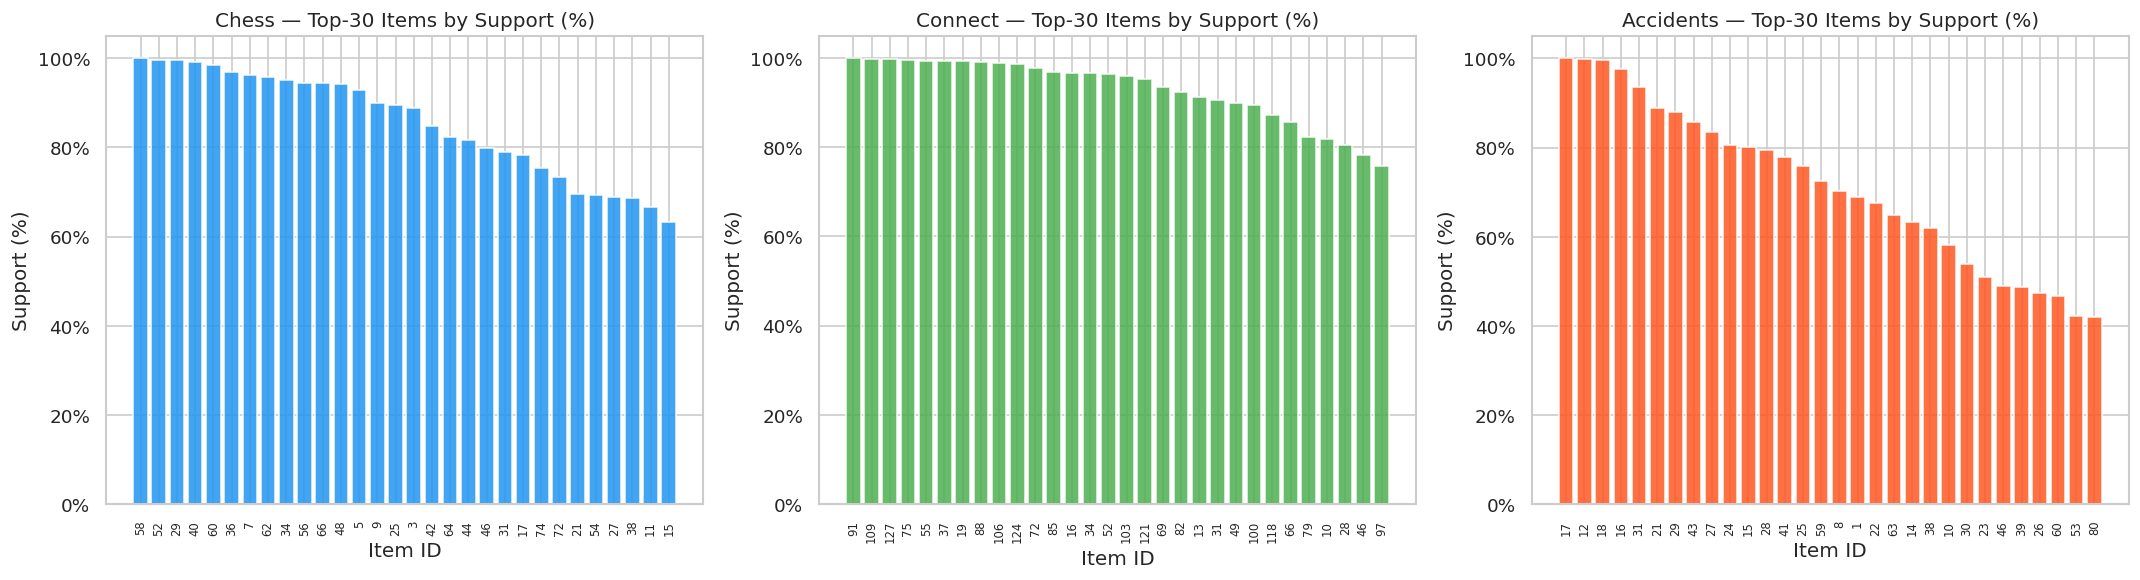

Figure saved: eda_item_support_top30.png


In [9]:
# ─── EDA Plot 2: Item Frequency Distribution (Top-30 Items) ──────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#2196F3', '#4CAF50', '#FF5722']

for ax, (name, item_counts), color in zip(axes, all_item_counts.items(), colors):
    num_tx = len(datasets[name])
    top30 = item_counts.most_common(30)
    items_labels = [str(i) for i, _ in top30]
    supports     = [c / num_tx * 100 for _, c in top30]

    ax.bar(range(30), supports, color=color, edgecolor='white', alpha=0.85)
    ax.set_xticks(range(30))
    ax.set_xticklabels(items_labels, rotation=90, fontsize=7)
    ax.set_title(f'{name.capitalize()} — Top-30 Items by Support (%)')
    ax.set_xlabel('Item ID')
    ax.set_ylabel('Support (%)')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

plt.tight_layout()
plt.savefig('./data/eda_item_support_top30.png', bbox_inches='tight')
plt.show()
print('Figure saved: eda_item_support_top30.png')

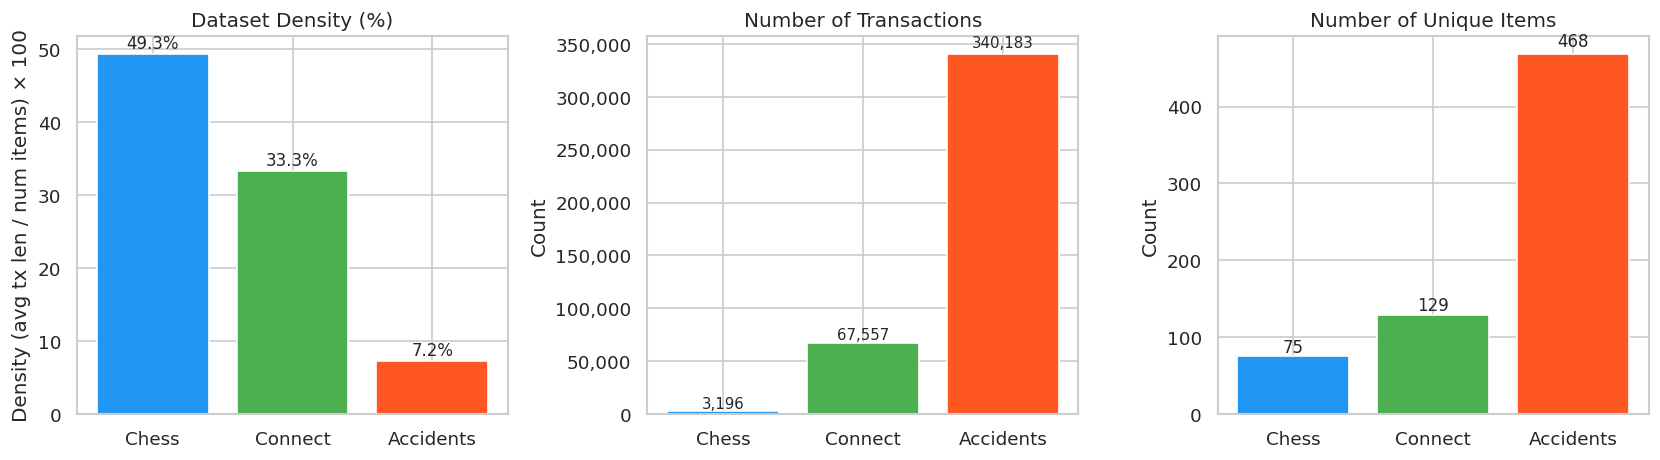

Figure saved: eda_dataset_comparison.png


In [10]:
# ─── EDA Plot 3: Dataset Density Comparison (Bar Chart) ──────────────────────

names    = [s['Dataset'] for s in all_stats]
densities = [s['Density (%)'] for s in all_stats]
num_txns = [s['# Transactions'] for s in all_stats]
num_items = [s['# Unique Items'] for s in all_stats]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Density
bars0 = axes[0].bar(names, densities, color=['#2196F3', '#4CAF50', '#FF5722'], edgecolor='white')
axes[0].set_title('Dataset Density (%)')
axes[0].set_ylabel('Density (avg tx len / num items) × 100')
for bar, val in zip(bars0, densities):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=10)

# Number of transactions
bars1 = axes[1].bar(names, num_txns, color=['#2196F3', '#4CAF50', '#FF5722'], edgecolor='white')
axes[1].set_title('Number of Transactions')
axes[1].set_ylabel('Count')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(bars1, num_txns):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                 f'{val:,}', ha='center', va='bottom', fontsize=9)

# Number of unique items
bars2 = axes[2].bar(names, num_items, color=['#2196F3', '#4CAF50', '#FF5722'], edgecolor='white')
axes[2].set_title('Number of Unique Items')
axes[2].set_ylabel('Count')
for bar, val in zip(bars2, num_items):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                 str(val), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('./data/eda_dataset_comparison.png', bbox_inches='tight')
plt.show()
print('Figure saved: eda_dataset_comparison.png')

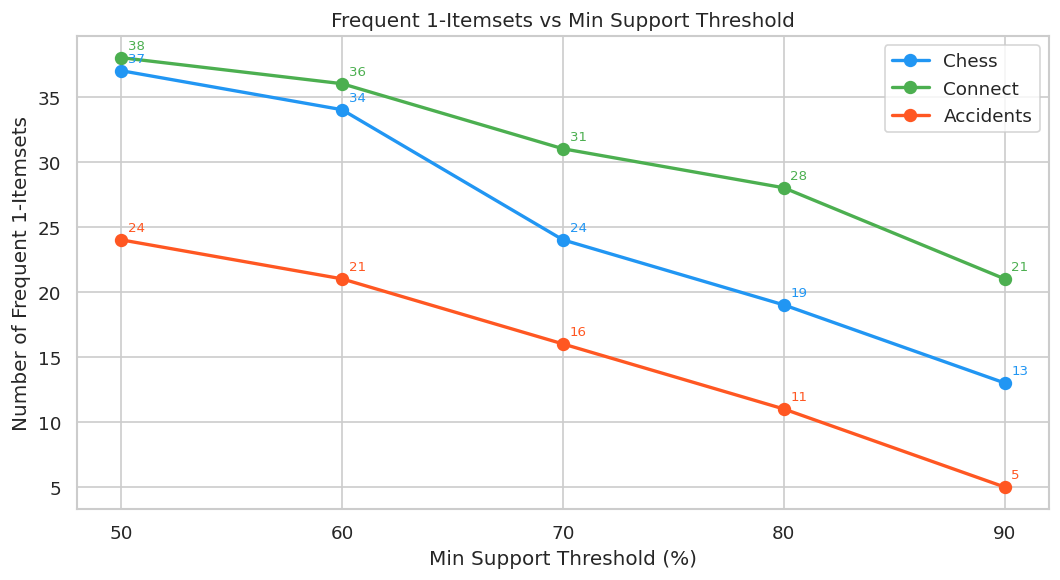

Figure saved: eda_freq1_vs_minsup.png


In [11]:
# ─── EDA Plot 4: Support Threshold vs Estimated Frequent 1-Itemsets ──────────
# This shows how many individual items would be 'frequent' at each threshold.
# Critical for understanding algorithm behavior.

MIN_SUP_THRESHOLDS = [0.50, 0.60, 0.70, 0.80, 0.90]

fig, ax = plt.subplots(figsize=(9, 5))
colors = {'chess': '#2196F3', 'connect': '#4CAF50', 'accidents': '#FF5722'}

for name, txns in datasets.items():
    num_tx = len(txns)
    item_counts = all_item_counts[name]
    freq_1itemsets = []
    for thresh in MIN_SUP_THRESHOLDS:
        min_count = thresh * num_tx
        freq_1 = sum(1 for c in item_counts.values() if c >= min_count)
        freq_1itemsets.append(freq_1)
    ax.plot([t*100 for t in MIN_SUP_THRESHOLDS], freq_1itemsets,
            marker='o', linewidth=2, markersize=7,
            color=colors[name], label=name.capitalize())
    for x, y in zip(MIN_SUP_THRESHOLDS, freq_1itemsets):
        ax.annotate(str(y), (x*100, y), textcoords='offset points',
                    xytext=(4, 5), fontsize=8, color=colors[name])

ax.set_title('Frequent 1-Itemsets vs Min Support Threshold')
ax.set_xlabel('Min Support Threshold (%)')
ax.set_ylabel('Number of Frequent 1-Itemsets')
ax.set_xticks([t*100 for t in MIN_SUP_THRESHOLDS])
ax.legend()
plt.tight_layout()
plt.savefig('./data/eda_freq1_vs_minsup.png', bbox_inches='tight')
plt.show()
print('Figure saved: eda_freq1_vs_minsup.png')

Computing co-occurrence matrix for Chess (top-20 items)...


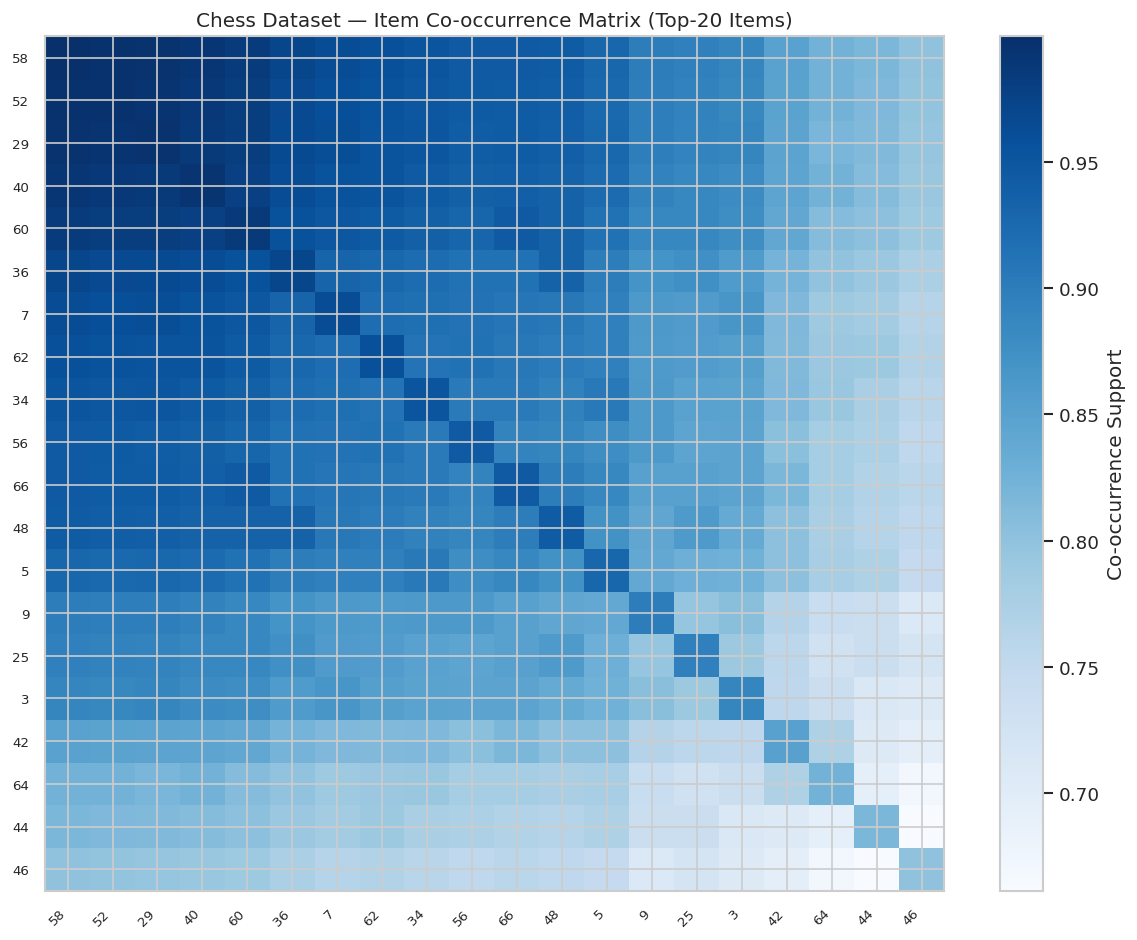

Figure saved: eda_chess_cooccurrence.png
NOTE: High values across the matrix confirm the dense nature of Chess.


In [12]:
# ─── EDA: Item Co-occurrence Heatmap (Top-20 Items, Chess) ───────────────────
# Shows correlation between items — important to explain why dense datasets
# are hard for Apriori (exponential candidates).

def cooccurrence_matrix(transactions, top_n=20):
    item_counts = Counter(item for t in transactions for item in t)
    top_items   = [item for item, _ in item_counts.most_common(top_n)]
    item_idx    = {item: i for i, item in enumerate(top_items)}
    n = len(top_items)
    matrix = np.zeros((n, n), dtype=np.int32)
    num_tx = len(transactions)
    for t in transactions:
        present = [item_idx[x] for x in t if x in item_idx]
        for i in range(len(present)):
            for j in range(i, len(present)):
                matrix[present[i]][present[j]] += 1
                if i != j:
                    matrix[present[j]][present[i]] += 1
    # Normalize by number of transactions → co-occurrence support
    matrix_norm = matrix / num_tx
    return top_items, matrix_norm


print('Computing co-occurrence matrix for Chess (top-20 items)...')
top_items_chess, cooc_chess = cooccurrence_matrix(datasets['chess'], top_n=20)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cooc_chess, cmap='Blues', aspect='auto')
ax.set_xticks(range(len(top_items_chess)))
ax.set_yticks(range(len(top_items_chess)))
ax.set_xticklabels([str(i) for i in top_items_chess], rotation=45, ha='right', fontsize=8)
ax.set_yticklabels([str(i) for i in top_items_chess], fontsize=8)
plt.colorbar(im, ax=ax, label='Co-occurrence Support')
ax.set_title('Chess Dataset — Item Co-occurrence Matrix (Top-20 Items)')
plt.tight_layout()
plt.savefig('./data/eda_chess_cooccurrence.png', bbox_inches='tight')
plt.show()
print('Figure saved: eda_chess_cooccurrence.png')
print('NOTE: High values across the matrix confirm the dense nature of Chess.')

In [13]:
# ─── Report-Ready Table: Frequent Items at Each Min-Sup Threshold ─────────────

print('='*80)
print('TABLE: Frequent 1-Itemsets at Each Min-Support Threshold (for Report Section 6)')
print('='*80)

table_rows = []
for thresh in MIN_SUP_THRESHOLDS:
    row = {'Min-Sup': f'{int(thresh*100)}%'}
    for name, txns in datasets.items():
        num_tx = len(txns)
        min_count = thresh * num_tx
        freq_1 = sum(1 for c in all_item_counts[name].values() if c >= min_count)
        row[name.capitalize()] = freq_1
    table_rows.append(row)

thresh_df = pd.DataFrame(table_rows).set_index('Min-Sup')
print(tabulate(thresh_df, headers='keys', tablefmt='grid'))
print()
print('NOTE: Higher # of frequent items → more candidate generation → harder for Apriori.')

TABLE: Frequent 1-Itemsets at Each Min-Support Threshold (for Report Section 6)
+-----------+---------+-----------+-------------+
| Min-Sup   |   Chess |   Connect |   Accidents |
+===========+=========+===========+=============+
| 50%       |      37 |        38 |          24 |
+-----------+---------+-----------+-------------+
| 60%       |      34 |        36 |          21 |
+-----------+---------+-----------+-------------+
| 70%       |      24 |        31 |          16 |
+-----------+---------+-----------+-------------+
| 80%       |      19 |        28 |          11 |
+-----------+---------+-----------+-------------+
| 90%       |      13 |        21 |           5 |
+-----------+---------+-----------+-------------+

NOTE: Higher # of frequent items → more candidate generation → harder for Apriori.


---
## Section 5: Dataset Preprocessing for Algorithms

We prepare the datasets in multiple formats needed by the algorithms in Notebooks 2–4:
- **Horizontal format** (list of frozensets) — Apriori, FP-Growth
- **Vertical format** (dict: item → set of TIDs) — ECLAT-style optimization
- **Item encoding** (items remapped to 0..N-1) — faster array indexing

In [14]:
# ─── Build Vertical Tidset Format ────────────────────────────────────────────

def build_vertical_format(transactions):
    """
    Convert horizontal transactions to vertical (tidset) format.
    Returns: dict {item: set_of_transaction_ids}
    """
    tidset = defaultdict(set)
    for tid, transaction in enumerate(transactions):
        for item in transaction:
            tidset[item].add(tid)
    return dict(tidset)


def remap_items(transactions):
    """
    Remap item IDs to a contiguous range [0, N-1].
    Returns: (remapped_transactions, item_to_idx, idx_to_item)
    """
    all_items = sorted({item for t in transactions for item in t})
    item_to_idx = {item: idx for idx, item in enumerate(all_items)}
    idx_to_item = {idx: item for item, idx in item_to_idx.items()}
    remapped = [frozenset(item_to_idx[i] for i in t) for t in transactions]
    return remapped, item_to_idx, idx_to_item


print('Building vertical tidset format and remapped datasets...')
vertical_datasets  = {}
remapped_datasets  = {}
item_mappings      = {}

for name, txns in datasets.items():
    vertical_datasets[name] = build_vertical_format(txns)
    remapped, i2idx, idx2i  = remap_items(txns)
    remapped_datasets[name] = remapped
    item_mappings[name]     = {'item_to_idx': i2idx, 'idx_to_item': idx2i}
    print(f'  [{name}] Vertical format: {len(vertical_datasets[name])} items, '
          f'{len(remapped_datasets[name])} transactions.')

print('\nDone.')

Building vertical tidset format and remapped datasets...
  [chess] Vertical format: 75 items, 3196 transactions.
  [connect] Vertical format: 129 items, 67557 transactions.
  [accidents] Vertical format: 468 items, 340183 transactions.

Done.


In [15]:
# ─── Verification: Cross-check vertical and horizontal support counts ─────────

def verify_support_consistency(name, transactions, vertical):
    """
    Verify that support computed in horizontal and vertical formats match
    for a sample of items.
    """
    sample_items = list(vertical.keys())[:5]
    num_tx = len(transactions)
    all_ok = True
    for item in sample_items:
        # Horizontal: count transactions containing item
        horiz_count = sum(1 for t in transactions if item in t)
        # Vertical: size of tidset
        vert_count  = len(vertical[item])
        match = '✓' if horiz_count == vert_count else '✗ MISMATCH'
        if horiz_count != vert_count:
            all_ok = False
        print(f'  [{name}] Item {item}: horizontal={horiz_count}, '
              f'vertical={vert_count} → {match}')
    return all_ok


print('Verifying support consistency (horizontal vs vertical)...')
for name in datasets:
    ok = verify_support_consistency(name, datasets[name], vertical_datasets[name])
    if ok:
        print(f'  [{name}] All checks passed.\n')
    else:
        print(f'  [{name}] VERIFICATION FAILED — check parsing.\n')

Verifying support consistency (horizontal vs vertical)...
  [chess] Item 1: horizontal=1669, vertical=1669 → ✓
  [chess] Item 3: horizontal=2839, vertical=2839 → ✓
  [chess] Item 5: horizontal=2971, vertical=2971 → ✓
  [chess] Item 7: horizontal=3076, vertical=3076 → ✓
  [chess] Item 9: horizontal=2874, vertical=2874 → ✓
  [chess] All checks passed.

  [connect] Item 1: horizontal=44473, vertical=44473 → ✓
  [connect] Item 4: horizontal=24982, vertical=24982 → ✓
  [connect] Item 7: horizontal=43385, vertical=43385 → ✓
  [connect] Item 10: horizontal=55333, vertical=55333 → ✓
  [connect] Item 13: horizontal=61616, vertical=61616 → ✓
  [connect] All checks passed.

  [accidents] Item 1: horizontal=234704, vertical=234704 → ✓
  [accidents] Item 2: horizontal=59300, vertical=59300 → ✓
  [accidents] Item 3: horizontal=6548, vertical=6548 → ✓
  [accidents] Item 4: horizontal=26713, vertical=26713 → ✓
  [accidents] Item 5: horizontal=96818, vertical=96818 → ✓
  [accidents] All checks passed.


---
## Section 6: Save Datasets for Subsequent Notebooks

In [16]:
# ─── Save to disk via pickle ──────────────────────────────────────────────────
# Notebooks 2, 3, 4 will load from these files instead of re-parsing.

SAVE_DIR = './data/processed'
os.makedirs(SAVE_DIR, exist_ok=True)

data_bundle = {
    'datasets':          datasets,           # horizontal: list of frozensets
    'vertical_datasets': vertical_datasets,  # vertical: item → set of TIDs
    'remapped_datasets': remapped_datasets,  # remapped: 0..N-1 item IDs
    'item_mappings':     item_mappings,      # item_to_idx, idx_to_item
    'all_stats':         all_stats,          # summary statistics list
    'MIN_SUP_THRESHOLDS': [0.50, 0.60, 0.70, 0.80, 0.90],
}

bundle_path = os.path.join(SAVE_DIR, 'data_bundle.pkl')
with open(bundle_path, 'wb') as f:
    pickle.dump(data_bundle, f, protocol=pickle.HIGHEST_PROTOCOL)

size_mb = os.path.getsize(bundle_path) / (1024*1024)
print(f'Data bundle saved to: {bundle_path}')
print(f'Bundle size: {size_mb:.2f} MB')
print('\nContents saved:')
for key in data_bundle:
    if isinstance(data_bundle[key], dict):
        print(f'  {key}: {list(data_bundle[key].keys())}')
    else:
        print(f'  {key}: {type(data_bundle[key])}')

Data bundle saved to: ./data/processed/data_bundle.pkl
Bundle size: 117.84 MB

Contents saved:
  datasets: ['chess', 'connect', 'accidents']
  vertical_datasets: ['chess', 'connect', 'accidents']
  remapped_datasets: ['chess', 'connect', 'accidents']
  item_mappings: ['chess', 'connect', 'accidents']
  all_stats: <class 'list'>
  MIN_SUP_THRESHOLDS: <class 'list'>


In [17]:
# ─── Optional: Mount Google Drive and Save There Too ─────────────────────────
# Uncomment the lines below to persist data across Colab sessions via Drive.
# This prevents re-downloading when your Colab session resets.

from google.colab import drive
drive.mount('/content/drive')
GDRIVE_DIR = '/content/drive/MyDrive/CS378_FIM_Project/'
os.makedirs(GDRIVE_DIR, exist_ok=True)
import shutil
shutil.copy(bundle_path, GDRIVE_DIR + 'data_bundle.pkl')
print('Saved to Google Drive.')

Mounted at /content/drive
Saved to Google Drive.


---
## Section 7: Full Dataset Summary Report

In [18]:
# ─── Final Summary ────────────────────────────────────────────────────────────

print('=' * 80)
print('NOTEBOOK 1 COMPLETE — DATASET SUMMARY')
print('=' * 80)

for name, txns in datasets.items():
    s = next(s for s in all_stats if s['Dataset'].lower() == name)
    print(f"\n{'─'*40}")
    print(f"  Dataset       : {name.upper()}")
    print(f"  Transactions  : {s['# Transactions']:,}")
    print(f"  Unique Items  : {s['# Unique Items']}")
    print(f"  Avg Tx Length : {s['Avg Tx Length']}")
    print(f"  Density       : {s['Density (%)']}%")
    print(f"  Classification: Dense (suitable for ProbDF comparison)")

print('\n' + '=' * 80)
print('FILES SAVED:')
print(f"  ./data/processed/data_bundle.pkl  — Parsed datasets (all formats)")
print(f"  ./data/eda_*.png                  — EDA figures for the report")
print('=' * 80)
print('\nNEXT: Run Notebook 2 — Apriori (Baseline) + Optimizations')
print('      Run Notebook 3 — FP-Growth (mlxtend) + ProbDF (2024)')
print('      Run Notebook 4 — Comparison, Metrics & Visualization')

NOTEBOOK 1 COMPLETE — DATASET SUMMARY

────────────────────────────────────────
  Dataset       : CHESS
  Transactions  : 3,196
  Unique Items  : 75
  Avg Tx Length : 37.0
  Density       : 49.33%
  Classification: Dense (suitable for ProbDF comparison)

────────────────────────────────────────
  Dataset       : CONNECT
  Transactions  : 67,557
  Unique Items  : 129
  Avg Tx Length : 43.0
  Density       : 33.33%
  Classification: Dense (suitable for ProbDF comparison)

────────────────────────────────────────
  Dataset       : ACCIDENTS
  Transactions  : 340,183
  Unique Items  : 468
  Avg Tx Length : 33.81
  Density       : 7.22%
  Classification: Dense (suitable for ProbDF comparison)

FILES SAVED:
  ./data/processed/data_bundle.pkl  — Parsed datasets (all formats)
  ./data/eda_*.png                  — EDA figures for the report

NEXT: Run Notebook 2 — Apriori (Baseline) + Optimizations
      Run Notebook 3 — FP-Growth (mlxtend) + ProbDF (2024)
      Run Notebook 4 — Comparison, Met

In [19]:
# ─── FULL VERIFICATION CELL ───────────────────────────────────────────────────
import os, pickle, json

ERRORS = []
WARNINGS = []

# ── 1. Check raw .dat files exist and are non-empty ──────────────────────────
print("=" * 60)
print("CHECK 1: Raw dataset files")
print("=" * 60)
for name in ['chess', 'connect', 'accidents']:
    path = f'./data/{name}.dat'
    if os.path.exists(path):
        mb = os.path.getsize(path) / 1024**2
        print(f"  [OK] {name}.dat  →  {mb:.2f} MB")
        if mb < 0.1:
            ERRORS.append(f"{name}.dat too small ({mb:.2f} MB) - likely corrupt")
    else:
        print(f"  [MISSING] {name}.dat")
        ERRORS.append(f"{name}.dat not found")

# ── 2. Check parsed datasets ──────────────────────────────────────────────────
print("\n" + "=" * 60)
print("CHECK 2: Parsed transaction counts (expected values)")
print("=" * 60)
EXPECTED = {
    'chess':     {'transactions': 3196,  'items': 75},
    'connect':   {'transactions': 67557, 'items': 129},
    'accidents': {'transactions': 340183,'items': 468},
}
for name, txns in datasets.items():
    exp = EXPECTED[name]
    n_tx = len(txns)
    n_items = len(set(i for t in txns for i in t))
    tx_ok  = "✓" if n_tx == exp['transactions'] else f"✗ EXPECTED {exp['transactions']}"
    it_ok  = "✓" if n_items == exp['items'] else f"✗ EXPECTED {exp['items']}"
    print(f"  [{name}]  transactions={n_tx} {tx_ok}  |  items={n_items} {it_ok}")
    if n_tx != exp['transactions']:
        ERRORS.append(f"{name}: transaction count mismatch")
    if n_items != exp['items']:
        WARNINGS.append(f"{name}: item count mismatch (FIMI versions differ)")

# ── 3. Check vertical format ──────────────────────────────────────────────────
print("\n" + "=" * 60)
print("CHECK 3: Vertical (tidset) format correctness")
print("=" * 60)
for name in datasets:
    v = vertical_datasets[name]
    txns = datasets[name]
    # Pick 3 random items and verify support both ways
    import random; random.seed(42)
    sample = random.sample(list(v.keys()), min(3, len(v)))
    ok = True
    for item in sample:
        horiz = sum(1 for t in txns if item in t)
        vert  = len(v[item])
        if horiz != vert:
            ok = False
            ERRORS.append(f"{name} item {item}: horiz={horiz} vert={vert}")
    status = "✓ all match" if ok else "✗ MISMATCH"
    print(f"  [{name}]  tidset spot-check → {status}")

# ── 4. Check remapped datasets ────────────────────────────────────────────────
print("\n" + "=" * 60)
print("CHECK 4: Remapped datasets (0..N-1 item IDs)")
print("=" * 60)
for name in datasets:
    rm = remapped_datasets[name]
    all_ids = set(i for t in rm for i in t)
    min_id, max_id = min(all_ids), max(all_ids)
    expected_max = len(all_ids) - 1
    ok = (min_id == 0) and (max_id == expected_max)
    status = "✓" if ok else f"✗ range [{min_id},{max_id}] expected [0,{expected_max}]"
    print(f"  [{name}]  ID range=[{min_id},{max_id}]  unique={len(all_ids)} → {status}")
    if not ok:
        ERRORS.append(f"{name} remapped IDs not contiguous 0..N-1")

# ── 5. Check pickle bundle ────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("CHECK 5: Pickle bundle")
print("=" * 60)
bundle_path = './data/processed/data_bundle.pkl'
if os.path.exists(bundle_path):
    with open(bundle_path, 'rb') as f:
        bundle = pickle.load(f)
    required_keys = ['datasets','vertical_datasets','remapped_datasets',
                     'item_mappings','all_stats','MIN_SUP_THRESHOLDS']
    for k in required_keys:
        status = "✓" if k in bundle else "✗ MISSING"
        print(f"  {status}  {k}")
        if k not in bundle:
            ERRORS.append(f"bundle missing key: {k}")
    mb = os.path.getsize(bundle_path) / 1024**2
    print(f"  Bundle size: {mb:.2f} MB")
else:
    print("  [MISSING] data_bundle.pkl not found")
    ERRORS.append("data_bundle.pkl not saved")

# ── 6. Check EDA figures ──────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("CHECK 6: EDA figures saved")
print("=" * 60)
figs = ['eda_transaction_length_dist.png','eda_item_support_top30.png',
        'eda_dataset_comparison.png','eda_freq1_vs_minsup.png',
        'eda_chess_cooccurrence.png']
for fig in figs:
    path = f'./data/{fig}'
    status = "✓" if os.path.exists(path) else "✗ MISSING"
    print(f"  {status}  {fig}")
    if not os.path.exists(path):
        WARNINGS.append(f"Figure {fig} not saved")

# ── 7. Quick support sanity check ────────────────────────────────────────────
print("\n" + "=" * 60)
print("CHECK 7: Support sanity at min_sup=0.80 (Chess)")
print("=" * 60)
chess_txns = datasets['chess']
n = len(chess_txns)
min_count = 0.80 * n
freq_items = {item for item, cnt in all_item_counts['chess'].items() if cnt >= min_count}
print(f"  Transactions : {n}")
print(f"  min_count    : {int(min_count)}  (80% of {n})")
print(f"  Frequent 1-itemsets at 80%: {len(freq_items)}")
print(f"  Expected ~20–35 for Chess at 80% → ", end="")
print("✓" if 10 <= len(freq_items) <= 60 else "✗ Unexpected value — check parsing")

# ── FINAL RESULT ──────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("FINAL RESULT")
print("=" * 60)
if not ERRORS:
    print("  ✅ ALL CHECKS PASSED — Notebook 1 is correct.")
else:
    print(f"  ❌ {len(ERRORS)} ERROR(S):")
    for e in ERRORS: print(f"     → {e}")
if WARNINGS:
    print(f"  ⚠  {len(WARNINGS)} WARNING(S):")
    for w in WARNINGS: print(f"     → {w}")

CHECK 1: Raw dataset files
  [OK] chess.dat  →  0.33 MB
  [OK] connect.dat  →  8.83 MB
  [OK] accidents.dat  →  33.86 MB

CHECK 2: Parsed transaction counts (expected values)
  [chess]  transactions=3196 ✓  |  items=75 ✓
  [connect]  transactions=67557 ✓  |  items=129 ✓
  [accidents]  transactions=340183 ✓  |  items=468 ✓

CHECK 3: Vertical (tidset) format correctness
  [chess]  tidset spot-check → ✓ all match
  [connect]  tidset spot-check → ✓ all match
  [accidents]  tidset spot-check → ✓ all match

CHECK 4: Remapped datasets (0..N-1 item IDs)
  [chess]  ID range=[0,74]  unique=75 → ✓
  [connect]  ID range=[0,128]  unique=129 → ✓
  [accidents]  ID range=[0,467]  unique=468 → ✓

CHECK 5: Pickle bundle
  ✓  datasets
  ✓  vertical_datasets
  ✓  remapped_datasets
  ✓  item_mappings
  ✓  all_stats
  ✓  MIN_SUP_THRESHOLDS
  Bundle size: 117.84 MB

CHECK 6: EDA figures saved
  ✓  eda_transaction_length_dist.png
  ✓  eda_item_support_top30.png
  ✓  eda_dataset_comparison.png
  ✓  eda_freq1_v